# *Setup*

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%%time
import numpy as np
import pandas as pd

from hid_avan.eda import head_tail_info
from hid_avan.preprocessing import extract_arrays_from_daily_pr_dataset
from hid_avan.modeling import build_timeseries_df_from_daily_avg_pr
from hid_avan.Thiessen import thiessen

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(context='notebook', style='ticks')
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'cm'

CPU times: total: 6.66 s
Wall time: 29.8 s


# Processando precipitações médias diárias

In [3]:
_, coord_array, pr_array = extract_arrays_from_daily_pr_dataset(funceme_txt_path='../data/raw/pr_daily_funceme_34750000_19730101_20260731.txt',
                                                                missing_pr_value=-999.)

In [4]:
%%time
avg_pr_array = thiessen(dados=pr_array.T,
                        lat=coord_array[:, 0],
                        lon=coord_array[:, 1],
                        pathshp='../data/raw/34750000.asc',
                        pf=-1, sep=',', usenc=False)

CPU times: total: 766 ms
Wall time: 1min 59s


In [6]:
#df = build_timeseries_df_from_daily_avg_pr(avg_pr_array=avg_pr_array,
#                                           date_start='1973-01-01', date_end='2026-07-31',
#                                           missing_pr_value=-999.)
#df.to_csv('../data/processed/timeseries_daily_avg_pr.csv', index=False)
df = pd.read_csv('../data/processed/timeseries_daily_avg_pr.csv', parse_dates=['date'])
head_tail_info(df)

<class 'pandas.DataFrame'>
RangeIndex: 19570 entries, 0 to 19569
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    19570 non-null  datetime64[us]
 1   avg_pr  19569 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 305.9 KB


,date,avg_pr
0,1973-01-01,NaN
1,1973-01-02,0.0
2,1973-01-03,0.0
3,1973-01-04,0.0
4,1973-01-05,0.3
19565,2026-07-27,0.0
19566,2026-07-28,0.0
19567,2026-07-29,0.0
19568,2026-07-30,0.0
19569,2026-07-31,0.0


None

# Agrupando em agregados mensais de precipitações médias

In [14]:
#df = pd.read_csv('../data/processed/timeseries_daily_avg_pr.csv', parse_dates=['date'])
#df_agg = df.groupby(by=pd.Grouper(key='date', freq='MS'),
#                    as_index=False).agg(agg_mean__avg_pr=('avg_pr', 'mean'))
#df_agg.to_csv('../data/processed/aggregated-by-mean_timeseries_monthly_avg_pr.csv', index=False)

df_agg = pd.read_csv('../data/processed/aggregated-by-mean_timeseries_monthly_avg_pr.csv', parse_dates=['date'])
head_tail_info(df_agg)

<class 'pandas.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              643 non-null    datetime64[us]
 1   agg_mean__avg_pr  643 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 10.2 KB


,date,agg_mean__avg_pr
0,1973-01-01,1.483333
1,1973-02-01,4.489286
2,1973-03-01,8.745161
3,1973-04-01,8.866667
4,1973-05-01,4.729032
638,2026-03-01,5.241654
639,2026-04-01,4.343600
640,2026-05-01,1.518898
641,2026-06-01,0.303568
642,2026-07-01,0.073574


None

# Montando o dataset `P-ETP-Q`

## *Joinando* `P` e `Q`

In [35]:
df_pr = pd.read_csv('../data/processed/aggregated-by-mean_timeseries_monthly_avg_pr.csv', parse_dates=['date'])
df_q  = pd.read_excel('../data/raw/34750000_Vazoes.xlsx', parse_dates=['Data'])
df_q.rename({'Data':'date', 'Media':'avg_q'}, axis='columns', inplace=True)
head_tail_info(df_pr, n=2)
head_tail_info(df_q, n=2)

<class 'pandas.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              643 non-null    datetime64[us]
 1   agg_mean__avg_pr  643 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 10.2 KB


,date,agg_mean__avg_pr
0,1973-01-01,1.483333
1,1973-02-01,4.489286
641,2026-06-01,0.303568
642,2026-07-01,0.073574


None

<class 'pandas.DataFrame'>
RangeIndex: 694 entries, 0 to 693
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    694 non-null    datetime64[us]
 1   avg_q   691 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 11.0 KB


,date,avg_q
0,1964-02-01,NaN
1,1964-03-01,279.9676
692,2021-11-01,4.4730
693,2021-12-01,1.3916


None

In [46]:
df_pr_q_right = df_pr.join(df_q.set_index('date'),
                           on='date', how='right')
df_pr_q_right.reset_index(drop=True, inplace=True)

df_pr_q_inner = df_pr.join(df_q.set_index('date'),
                           on='date', how='inner')
df_pr_q_inner.reset_index(drop=True, inplace=True)

df_pr_q_right.to_csv('../data/processed/pr-q_monthly_right-joined.csv', index=False)
df_pr_q_inner.to_csv('../data/processed/pr-q_monthly_inner-joined.csv', index=False)

## `ETP`

In [3]:
df_normais_clim_stations = pd.read_excel('../data/raw/Normal-Climatologica-ESTACOES.xlsx', header=2)
#df_normais_clim_stations = df_normais_clim_stations.loc[:, ['Código', 'Latitude', 'Longitude']]
head_tail_info(df_normais_clim_stations)

<class 'pandas.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Nº               267 non-null    int64         
 1   Código           267 non-null    int64         
 2   Nome da Estação  267 non-null    str           
 3   UF               267 non-null    str           
 4   Latitude         267 non-null    float64       
 5   Longitude        267 non-null    float64       
 6   Atitude          267 non-null    float64       
 7   Inicio Operação  267 non-null    object        
 8   Fim Operação     155 non-null    datetime64[us]
 9   Situação         267 non-null    str           
dtypes: datetime64[us](1), float64(3), int64(2), object(1), str(3)
memory usage: 21.0+ KB


,Nº,Código,Nome da Estação,UF,Latitude,Longitude,Atitude,Inicio Operação,Fim Operação,Situação
0,1,82704,CRUZEIRO DO SUL,AC,-7.610833,-72.681389,214.19,1928-01-01 00:00:00,2016-01-30,Desativada
1,2,82915,RIO BRANCO,AC,-9.959167,-67.868889,160.71,1929-01-01 00:00:00,2023-08-15,Fechada
2,3,82807,TARAUACÁ,AC,-8.160278,-70.768611,172.27,1966-06-06 00:00:00,NaT,Operante
3,4,82989,ÁGUA BRANCA,AL,-9.264722,-37.938056,603.42,1928-05-05 00:00:00,2023-02-22,Fechada
4,5,82994,MACEIÓ,AL,-9.551389,-35.770833,84.12,1909-01-01 00:00:00,2021-04-08,Fechada
262,263,83033,PALMAS,TO,-10.147778,-48.314444,267.00,1993-10-08 00:00:00,NaT,Operante
263,264,82863,PEDRO AFONSO,TO,-8.968611,-48.177222,189.53,1977-03-04 00:00:00,NaT,Operante
264,265,83228,PEIXE,TO,-12.015278,-48.545000,252.24,1975-05-01 00:00:00,NaT,Operante
265,266,83064,PORTO NACIONAL,TO,-10.710833,-48.406389,243.28,1915-01-01 00:00:00,NaT,Operante
266,267,83235,TAGUATINGA,TO,-12.402222,-46.438333,604.88,1915-12-22 00:00:00,NaT,Operante


None

In [6]:
df_basin = pd.read_csv('../data/raw/34750000.txt', header=None)
df_basin.rename({1:'Latitude', 0:'Longitude'}, axis='columns', inplace=True)
head_tail_info(df_basin)

<class 'pandas.DataFrame'>
RangeIndex: 8090 entries, 0 to 8089
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Longitude  8090 non-null   float64
 1   Latitude   8090 non-null   float64
dtypes: float64(2)
memory usage: 126.5 KB


,Longitude,Latitude
0,-40.814582,-4.626249
1,-40.813749,-4.626249
2,-40.813749,-4.627083
3,-40.814582,-4.627083
4,-40.814582,-4.627916
8085,-40.812916,-4.623749
8086,-40.813749,-4.623749
8087,-40.813749,-4.624583
8088,-40.814582,-4.624583
8089,-40.814582,-4.626249


None

In [16]:
df_basin['Latitude'].max()

np.float64(-4.08541585)

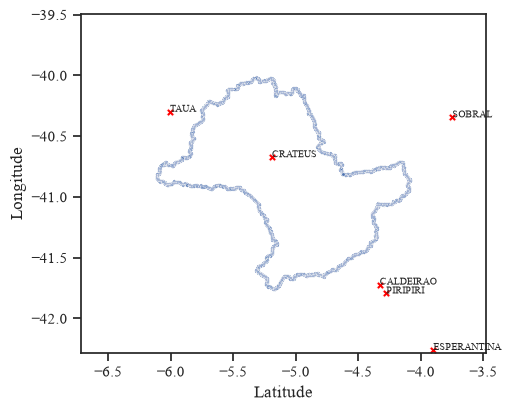

In [25]:
fac = 0.3
lat_min = df_basin['Latitude'].min() - np.ptp(df_basin['Latitude']) * fac
lat_max = df_basin['Latitude'].max() + np.ptp(df_basin['Latitude']) * fac
lon_min = df_basin['Longitude'].min() - np.ptp(df_basin['Longitude']) * fac
lon_max = df_basin['Longitude'].max() + np.ptp(df_basin['Longitude']) * fac

df_queried = df_normais_clim_stations.query(f'Latitude > {lat_min} and Latitude < {lat_max} and Longitude > {lon_min} and Longitude < {lon_max}')

fig, ax = plt.subplots(1, 1, figsize=(5, 4), layout='constrained')
sns.scatterplot(ax=ax, data=df_basin, x='Latitude', y='Longitude', s=5)
sns.scatterplot(ax=ax, data=df_queried, x='Latitude', y='Longitude', color='red', marker='X', s=30)
ax.set_xlim(lat_min, lat_max)
ax.set_ylim(lon_min, lon_max)
for lat, lon, name in zip(df_queried['Latitude'], df_queried['Longitude'], df_queried['Nome da Estação']):
    ax.text(x=lat, y=lon, s=name, size=7)
plt.show()

In [3]:
df_normais_clim = pd.read_excel('../data/raw/Normal-Climatologica-EVAPOTM.xlsx', header=2)
df_normais_clim.rename({'Código ':'Código'}, axis='columns', inplace=True)
df_normais_clim.where(df_normais_clim != '- ', np.nan, inplace=True)
df_normais_clim = df_normais_clim.astype( dict( zip( df_normais_clim.columns[3:], ['float64']*13 ) ) )

head_tail_info(df_normais_clim)

<class 'pandas.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Código           146 non-null    int64  
 1   Nome da Estação  146 non-null    str    
 2   UF               146 non-null    str    
 3   Janeiro          133 non-null    float64
 4   Fevereiro        144 non-null    float64
 5   Março            143 non-null    float64
 6   Abril            143 non-null    float64
 7   Maio             144 non-null    float64
 8   Junho            142 non-null    float64
 9   Julho            138 non-null    float64
 10  Agosto           143 non-null    float64
 11  Setembro         142 non-null    float64
 12  Outubro          145 non-null    float64
 13  Novembro         146 non-null    float64
 14  Dezembro         144 non-null    float64
 15  Ano              110 non-null    float64
dtypes: float64(13), int64(1), str(2)
memory usage: 18.4 KB


,Código,Nome da Estação,UF,Janeiro,Fevereiro,Março,Abril,Maio,Junho,Julho,Agosto,Setembro,Outubro,Novembro,Dezembro,Ano
0,83249,ALAGOINHAS,BA,176.5,155.1,170.4,145.1,126.2,99.8,92.8,95.4,109.6,143.9,156.7,174.7,1646.2
1,82970,ALTO PARNAIBA,MA,183.5,158.9,168.7,155.1,158.5,137.7,137.4,171.2,216.3,244.6,213.0,195.7,2140.6
2,83096,ARACAJU,SE,178.5,166.4,180.8,168.4,153.7,133.6,122.2,125.0,132.5,150.2,159.1,174.9,1845.3
3,83442,ARACUAI,MG,210.3,189.3,188.7,158.0,134.5,102.5,104.0,139.6,181.1,239.1,207.2,197.8,2052.1
4,83368,ARAGARCAS,GO,204.5,172.4,184.0,163.7,140.8,115.0,118.6,183.4,234.4,259.7,215.9,220.1,2212.5
141,83927,URUGUAIANA,RS,210.2,163.2,154.1,116.1,88.4,71.3,76.9,98.4,113.0,138.6,167.9,207.6,1605.7
142,82870,VALE DO GURGUEIA (CRISTIANO CASTRO),PI,201.2,160.5,170.2,158.8,174.3,165.4,173.0,NaN,NaN,296.3,274.4,221.3,NaN
143,83642,VICOSA,MG,136.7,117.2,118.4,99.5,78.6,63.7,63.5,81.4,101.2,124.9,125.7,133.9,1244.7
144,83648,VITORIA,ES,206.0,184.1,192.3,164.5,133.1,109.9,106.2,112.5,129.4,164.6,176.0,196.2,1874.8
145,82376,ZE DOCA,MA,191.6,161.1,167.4,162.0,176.3,164.6,166.9,180.4,186.8,202.7,203.3,210.8,2173.9


None

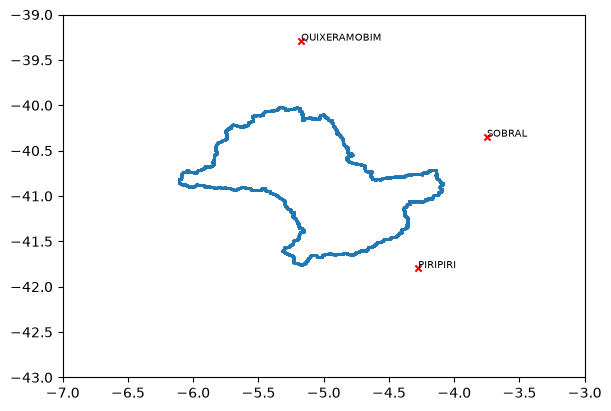

In [67]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')
ax.scatter(x=df[1], y=df[0], s=1)
ax.set_xlim(-7., -3)
ax.set_ylim(-43., -39.)

df_queried = df_normais_clim.query('Latitude > -7. and Latitude < -3. and Longitude > -43. and Longitude < -39.')

ax.scatter(x=df_queried['Latitude'],
           y=df_queried['Longitude'], color='red', marker='x', s=20)
for lat, lon, name in zip(df_queried['Latitude'], df_queried['Longitude'], df_queried['Nome da Estação']):
    ax.text(x=lat, y=lon, s=name, size=7)
plt.show()

In [66]:
df_normais_clim = df_normais_clim.join(df_normais_clim_stations.set_index('Código'),
                                       on='Código', how='left')
df_normais_clim = df_normais_clim.iloc[:, [0, -2, -1] + list(range(1, df_normais_clim.shape[1]-2))]
head_tail_info(df_normais_clim)

<class 'pandas.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Código           146 non-null    int64  
 1   Latitude         146 non-null    float64
 2   Longitude        146 non-null    float64
 3   Nome da Estação  146 non-null    str    
 4   UF               146 non-null    str    
 5   Janeiro          133 non-null    float64
 6   Fevereiro        144 non-null    float64
 7   Março            143 non-null    float64
 8   Abril            143 non-null    float64
 9   Maio             144 non-null    float64
 10  Junho            142 non-null    float64
 11  Julho            138 non-null    float64
 12  Agosto           143 non-null    float64
 13  Setembro         142 non-null    float64
 14  Outubro          145 non-null    float64
 15  Novembro         146 non-null    float64
 16  Dezembro         144 non-null    float64
 17  Ano              110 non-nu

,Código,Latitude,Longitude,Nome da Estação,UF,Janeiro,Fevereiro,Março,Abril,Maio,Junho,Julho,Agosto,Setembro,Outubro,Novembro,Dezembro,Ano
0,83249,-12.148611,-38.425278,ALAGOINHAS,BA,176.5,155.1,170.4,145.1,126.2,99.8,92.8,95.4,109.6,143.9,156.7,174.7,1646.2
1,82970,-9.108333,-45.948611,ALTO PARNAIBA,MA,183.5,158.9,168.7,155.1,158.5,137.7,137.4,171.2,216.3,244.6,213.0,195.7,2140.6
2,83096,-10.952500,-37.054444,ARACAJU,SE,178.5,166.4,180.8,168.4,153.7,133.6,122.2,125.0,132.5,150.2,159.1,174.9,1845.3
3,83442,-16.848889,-42.060833,ARACUAI,MG,210.3,189.3,188.7,158.0,134.5,102.5,104.0,139.6,181.1,239.1,207.2,197.8,2052.1
4,83368,-15.902500,-52.245278,ARAGARCAS,GO,204.5,172.4,184.0,163.7,140.8,115.0,118.6,183.4,234.4,259.7,215.9,220.1,2212.5
141,83927,-29.840000,-57.081944,URUGUAIANA,RS,210.2,163.2,154.1,116.1,88.4,71.3,76.9,98.4,113.0,138.6,167.9,207.6,1605.7
142,82870,-8.441667,-43.865556,VALE DO GURGUEIA (CRISTIANO CASTRO),PI,201.2,160.5,170.2,158.8,174.3,165.4,173.0,NaN,NaN,296.3,274.4,221.3,NaN
143,83642,-20.762500,-42.863889,VICOSA,MG,136.7,117.2,118.4,99.5,78.6,63.7,63.5,81.4,101.2,124.9,125.7,133.9,1244.7
144,83648,-20.315833,-40.316944,VITORIA,ES,206.0,184.1,192.3,164.5,133.1,109.9,106.2,112.5,129.4,164.6,176.0,196.2,1874.8
145,82376,-3.269167,-45.651111,ZE DOCA,MA,191.6,161.1,167.4,162.0,176.3,164.6,166.9,180.4,186.8,202.7,203.3,210.8,2173.9


None

In [133]:
df_normais_clim_PI = df_normais_clim[df_normais_clim['UF'] == 'PI']
display(df_normais_clim_PI)

df_normais_clim_PI.dropna(axis='rows', inplace=True)
display(df_normais_clim_PI)

,Código,Latitude,Longitude,Nome da Estação,UF,Janeiro,Fevereiro,Março,Abril,Maio,Junho,Julho,Agosto,Setembro,Outubro,Novembro,Dezembro,Ano
25,82975,-9.080000,-44.327778,BOM JESUS DO PIAUI,PI,NaN,224.0,234.3,209.3,216.6,197.8,210.8,245.1,290.3,320.1,287.2,279.1,NaN
55,82678,-6.761667,-43.003333,FLORIANO,PI,222.3,175.5,179.9,172.2,185.0,187.2,219.2,272.5,325.2,355.2,314.6,265.1,2873.9
103,82882,-8.132222,-41.143056,PAULISTANA,PI,237.8,189.2,191.9,167.8,184.7,NaN,163.3,189.4,245.5,289.3,287.3,275.3,NaN
109,82480,-4.276111,-41.794444,PIRIPIRI,PI,215.0,171.0,166.2,151.9,158.6,156.9,178.3,197.8,217.4,243.4,247.3,253.9,2357.7
126,82879,-8.365000,-42.250278,SAO JOAO DO PIAUI,PI,242.1,189.4,189.5,179.5,194.3,181.5,186.8,224.9,274.0,317.9,312.6,281.0,2773.5
142,82870,-8.441667,-43.865556,VALE DO GURGUEIA (CRISTIANO CASTRO),PI,201.2,160.5,170.2,158.8,174.3,165.4,173.0,NaN,NaN,296.3,274.4,221.3,NaN


,Código,Latitude,Longitude,Nome da Estação,UF,Janeiro,Fevereiro,Março,Abril,Maio,Junho,Julho,Agosto,Setembro,Outubro,Novembro,Dezembro,Ano
55,82678,-6.761667,-43.003333,FLORIANO,PI,222.3,175.5,179.9,172.2,185.0,187.2,219.2,272.5,325.2,355.2,314.6,265.1,2873.9
109,82480,-4.276111,-41.794444,PIRIPIRI,PI,215.0,171.0,166.2,151.9,158.6,156.9,178.3,197.8,217.4,243.4,247.3,253.9,2357.7
126,82879,-8.365000,-42.250278,SAO JOAO DO PIAUI,PI,242.1,189.4,189.5,179.5,194.3,181.5,186.8,224.9,274.0,317.9,312.6,281.0,2773.5
